# The following analysis explores the Spokane Water Heater permits from the last 20 years. 


How often do water heaters stop working?
How often do electic water heaters need to be replaced?
What is the Day, Month, Year of water heater distrobution?
Where do most people with electric water heaters live?
Are the political affilitaions of people that use electric water heaters?


The analysis will merge 4 different datasets: Voting records, Political affiliation, and Spokane Water heater permits, and a shapefile of Spokane Voter precincts.

The voting records have precinct, so the address will be matched with water heaters and voting records to be explored via precinct map.

How long do electric water heaters last?


In [1]:
#-- Import the nessesary libraries --#

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shapefile
import os
#-- Libraries needed to generate the report --#

from shapely.geometry import shape
from shapely.geometry import Polygon
from shapely.validation import make_valid
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Image, Spacer,Paragraph
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.platypus import Table, TableStyle
from reportlab.lib import colors

In [2]:
#-- Importing the dataset --#
df = pd.read_csv('/Users/michaelsegaline/Desktop/Water Heater permits analysis/Spokane_Water_Heaters.csv')

In [3]:
#-- Inspecting the head --#
df.head()

,Record ID,Water Heater Type,Quantity,Open Date,Address,City,State
0,B0500015,"Gas Water Heaters < 200,000 BTU input",1.0,1/3/05 0:00,4012 W HIAWATHA DR,SPOKANE,WA
1,B0500050,"Gas Water Heaters < 200,000 BTU input",1.0,1/4/05 0:00,1326 E OLYMPIC AVE,SPOKANE,WA
2,B0500054,"Gas Water Heaters < 200,000 BTU input",1.0,1/4/05 0:00,4449 N LIDGERWOOD ST,SPOKANE,WA
3,B0500080,"Gas Water Heaters < 200,000 BTU input",1.0,1/4/05 0:00,1429 S WALNUT ST,SPOKANE,WA
4,B0500086,"Gas Water Heaters < 200,000 BTU input",1.0,1/5/05 0:00,2533 E 27TH AVE,SPOKANE,WA


In [4]:
#-- Getting the shape--#
df.shape

(20017, 7)

In [71]:
df.columns

Index(['Record ID', 'Water Heater Type', 'Quantity', 'Open Date', 'Address',
       'City', 'State', 'open_year', 'open_month', 'open_day'],
      dtype='object')

In [5]:
# all rows whose Address appears more than once
dup_addr_mask = df.duplicated(subset=['Address'], keep=False)
df_dup_address = df[dup_addr_mask]
df_dup_address

,Record ID,Water Heater Type,Quantity,Open Date,Address,City,State
1,B0500050,"Gas Water Heaters < 200,000 BTU input",1.0,1/4/05 0:00,1326 E OLYMPIC AVE,SPOKANE,WA
4,B0500086,"Gas Water Heaters < 200,000 BTU input",1.0,1/5/05 0:00,2533 E 27TH AVE,SPOKANE,WA
13,B0500196,"Gas Water Heaters < 200,000 BTU input",1.0,1/7/05 0:00,3315 S CRESTLINE ST,SPOKANE,WA
25,B0500230,"Gas Water Heaters < 200,000 BTU input",1.0,1/10/05 0:00,229 W HEROY AVE,SPOKANE,WA
30,B0500259,"Gas Water Heaters < 200,000 BTU input",1.0,1/11/05 0:00,8019 N PANORAMA DR,SPOKANE,WA
...,...,...,...,...,...,...,...
20009,B2422818MECH,"Gas Water Heaters < 200,000 BTU input",1.0,12/31/24 0:00,1928 W INDIANA AVE,SPOKANE,WA
20010,B2422826MECH,"Gas Water Heaters < 200,000 BTU input",1.0,12/31/24 0:00,523 W 26TH AVE,SPOKANE,WA
20013,B2422837MECH,"Gas Water Heaters < 200,000 BTU input",1.0,12/31/24 0:00,3331 W BEACON AVE,SPOKANE,WA
20015,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Now fining the number duplicate addresses percentage.

In [6]:
3496/20017

0.1746515461857421

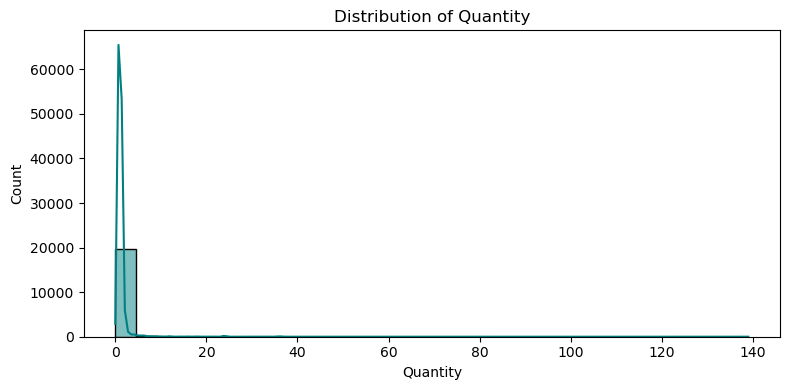

In [7]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Quantity', bins=30, kde=True, color='teal')
plt.title('Distribution of Quantity')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

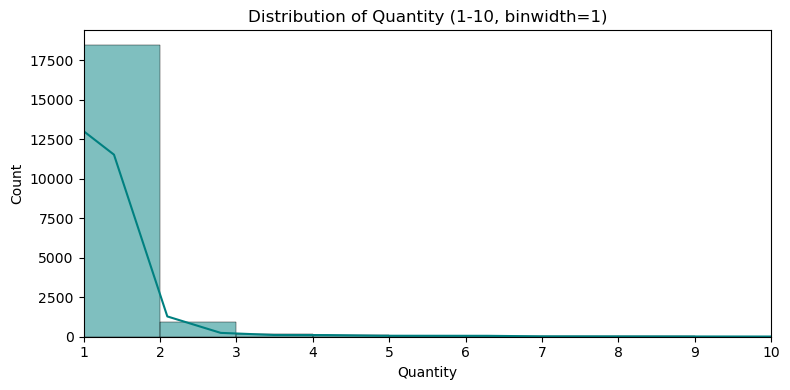

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Quantity', binwidth=1, kde=True, color='teal')
plt.title('Distribution of Quantity (1-10, binwidth=1)')
plt.xlabel('Quantity')
plt.ylabel('Count')
plt.xlim(1, 10)
plt.tight_layout()
plt.savefig("Distobution of Quantity.png")
plt.show()

In [9]:
# tally of addresses, most frequent first
addr_counts = df['Address'].value_counts()

# top 100 addresses with their counts
top_100_addresses = addr_counts.head(50)

print(top_100_addresses)


1605 N RIVER RIDGE BLVD         29
601 W RIVERSIDE AVE             28
4750 N DIVISION ST              22
808 W MAIN AVE                  22
3080 N HEMLOCK ST               22
849 E Magnesium RD              20
3405 S COOK ST                  18
1120 W SPRAGUE AVE              17
1723 W 7TH AVE                  17
502 E BOONE AVE                 17
3724 N COOK ST                  14
700 W 7TH AVE                   14
118 E DESMET AVE                13
5420 W BARNES RD                13
6105 E RUTTER AVE               13
3102 S MOUNT VERNON ST          13
1224 W RIVERSIDE AVE            12
401 W 1ST AVE                   12
224 E SHARP AVE                 12
3210 E 44TH AVE                 12
4727 N DIVISION ST              12
2711 E Adirondack LN            12
3431 S COOK ST                  12
121 E Wedgewood AVE             11
820 N POST ST                   11
7125 N Crestline ST             11
601 E SHARP AVE                 11
975 E NORTH FOOTHILLS DR        10
707 W MAIN AVE      

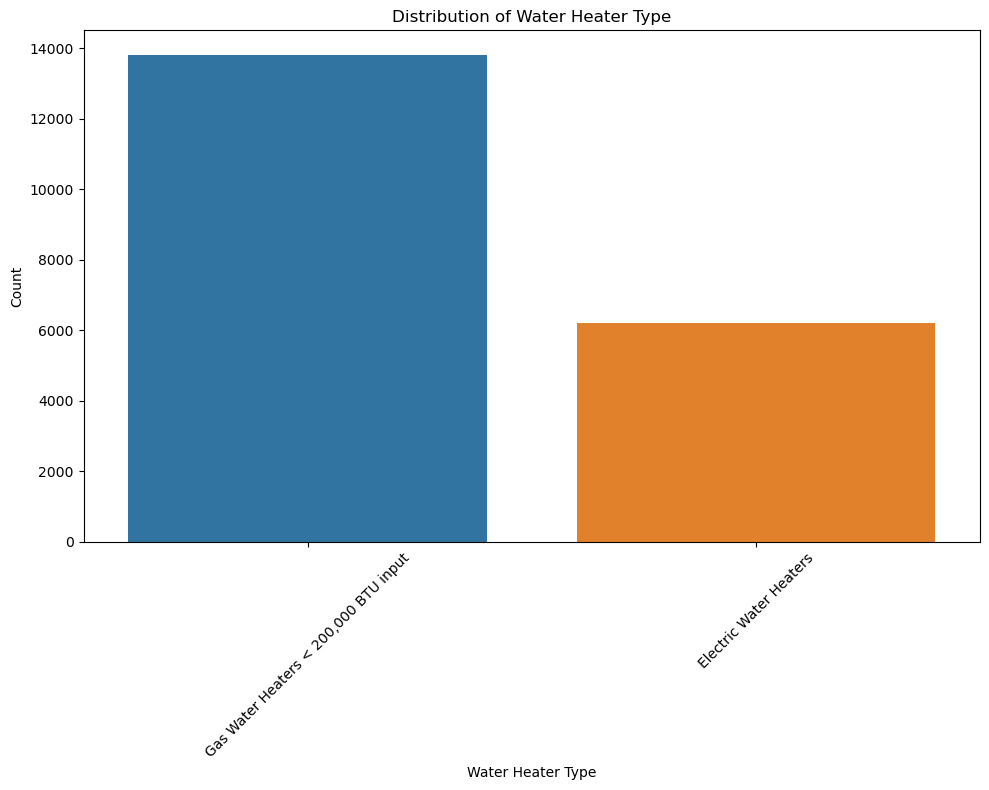

In [10]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Water Heater Type', data=df, order=df['Water Heater Type'].value_counts().index)
plt.title('Distribution of Water Heater Type')
plt.xlabel('Water Heater Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("Water Heater Type.png")
plt.show()

Cleaning the Open Date column and splitting the date into seperate columns of day/mon/yr

In [11]:
# convert to datetime (handles '1/4/2005 12:00:00 AM')
df['Open Date'] = pd.to_datetime(df['Open Date'], errors='coerce')

# drop time part, keep only date
df['Open Date'] = df['Open Date'].dt.date


In [12]:
# convert back to datetime to use .dt accessor
df['Open Date'] = pd.to_datetime(df['Open Date'])

df['open_year'] = df['Open Date'].dt.year
df['open_month'] = df['Open Date'].dt.month
df['open_day'] = df['Open Date'].dt.day


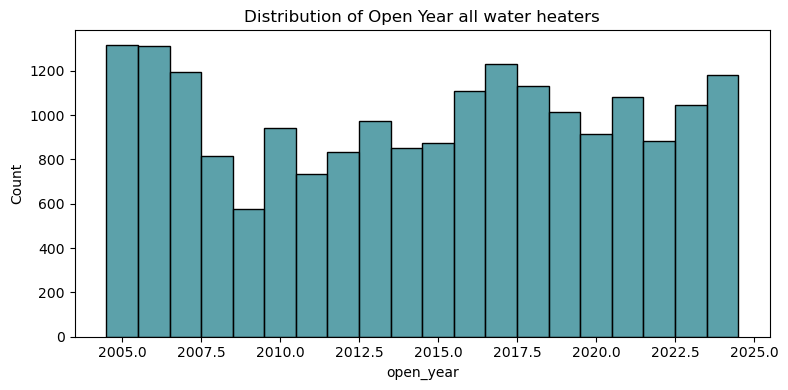

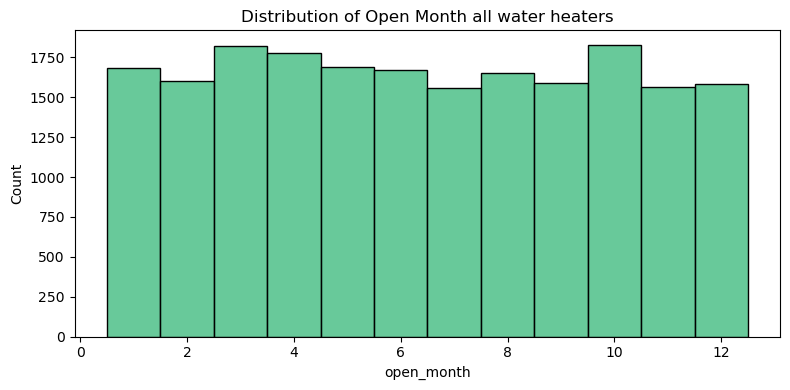

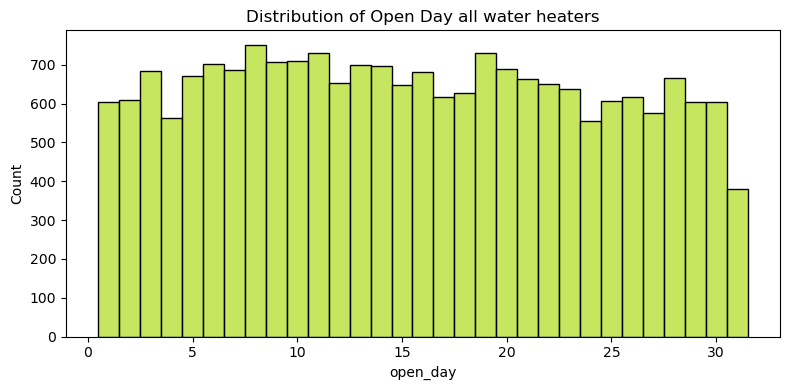

In [72]:
palette = sns.color_palette('viridis', 8)  # exactly 8 colors

plt.figure(figsize=(8,4))
sns.histplot(data=df, x='open_year',  discrete=True, color=palette[3])
plt.title('Distribution of Open Year all water heaters')
plt.tight_layout()
plt.savefig('All Years.png')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(data=df, x='open_month', discrete=True, color=palette[5])
plt.title('Distribution of Open Month all water heaters')
plt.tight_layout()
plt.savefig('All Months.png')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(data=df, x='open_day',   discrete=True, color=palette[7])
plt.title('Distribution of Open Day all water heaters')
plt.tight_layout()
plt.savefig('All Days.png')
plt.show()

# How many water heater permits are filed per year?

In [14]:
#--Getting descriptive statistics --#
df["open_year"].value_counts().sort_index().mean()

1000.75

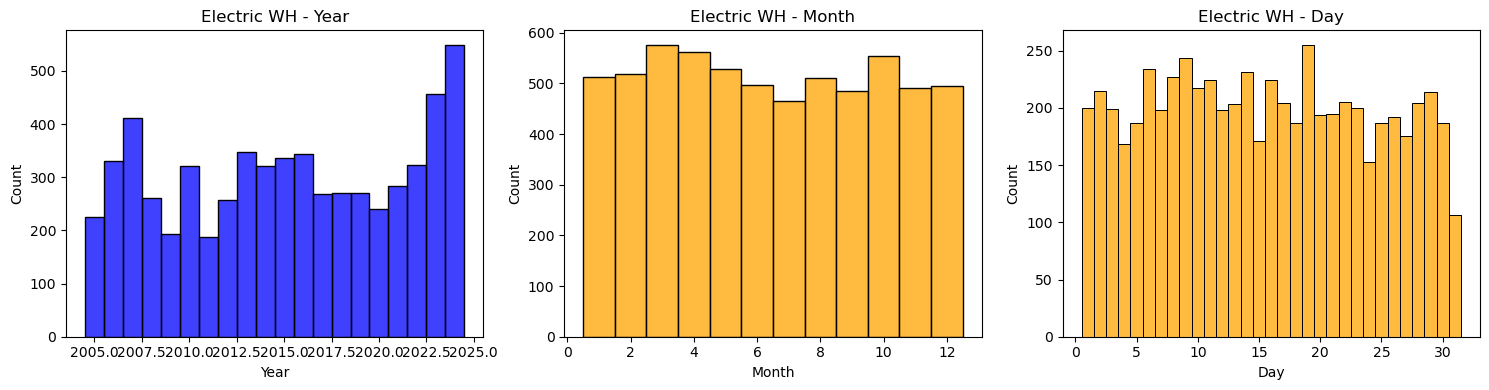

In [15]:
electric_wh = df[df['Water Heater Type'] == 'Electric Water Heaters']

# histograms

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=electric_wh, x='open_year', discrete=True, ax=axes[0], color='blue')
axes[0].set_title('Electric WH - Year')
axes[0].set_xlabel('Year')

sns.histplot(data=electric_wh, x='open_month', discrete=True, ax=axes[1], color='orange')
axes[1].set_title('Electric WH - Month')
axes[1].set_xlabel('Month')

sns.histplot(data=electric_wh, x='open_day', discrete=True, ax=axes[2], color='orange')
axes[2].set_title('Electric WH - Day')
axes[2].set_xlabel('Day')

plt.tight_layout()

plt.savefig("Electric Permit Time Distrobutions.png")
plt.show()

# Now connecting the Spokane voter dataset to Spokane water heaters permits on Address.

In [16]:
#-- Importing the Voter dataset --#
df2 = pd.read_csv('/Users/michaelsegaline/Desktop/Washington GOP/county registered voters /2025-10-09-Spokane County VRB Current.csv')

/var/folders/_5/26fwgmd14qz8pgwfvn4dfky40000gn/T/ipykernel_22203/2705792548.py:2: DtypeWarning: Columns (8,13,17,24) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('/Users/michaelsegaline/Desktop/Washington GOP/county registered voters /2025-10-09-Spokane County VRB Current.csv')


In [17]:
df.Address

0          4012 W HIAWATHA DR
1          1326 E OLYMPIC AVE
2        4449 N LIDGERWOOD ST
3            1429 S WALNUT ST
4             2533 E 27TH AVE
                 ...         
20012          5917 N WALL ST
20013       3331 W BEACON AVE
20014        2323 W GLASS AVE
20015                     NaN
20016                     NaN
Name: Address, Length: 20017, dtype: object

Cleaning up the trailing zeros in the Address column more

In [18]:
df2.columns

Index(['StateVoterID', 'FName', 'MName', 'LName', 'NameSuffix', 'Birthyear',
       'Gender', 'RegStNum', 'RegStFrac', 'RegStName', 'RegStType',
       'RegUnitType', 'RegStPreDirection', 'RegStPostDirection',
       'RegStUnitNum', 'RegCity', 'RegState', 'RegZipCode', 'CountyCode',
       'PrecinctCode', 'PrecinctPart', 'LegislativeDistrict',
       'CongressionalDistrict', 'Mail1', 'Mail2', 'Mail3', 'MailCity',
       'MailZip', 'MailState', 'MailCountry', 'Registrationdate', 'LastVoted',
       'StatusCode', 'Count', 'Reg Month', 'Reg Year',
       'First name = middle name', 'first name = last name'],
      dtype='object')

# Engineering the Address column to merge Spokane Water Permits Address w/ Voter Address.

In [19]:
# 1) Build Address in df2: "4012 W HIAWATHA DR"
df2['Address'] = (
    df2['RegStNum'].astype(str).str.strip() + ' ' +
    df2['RegStPreDirection'].fillna('').astype(str).str.strip() + ' ' +
    df2['RegStName'].astype(str).str.strip() + ' ' +
    df2['RegStType'].astype(str).str.strip()
)

# collapse multiple spaces, strip, and uppercase to match df
df2['Address'] = (
    df2['Address']
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.upper()
)

# 2) Make sure df.Address is in same cleaned form (no city/state, you already fixed in Excel)
df['Address'] = (
    df['Address'].astype(str)
      .str.replace(r'\s+', ' ', regex=True)
      .str.strip()
      .str.upper()
)

# 3) Merge on Address
merged = df.merge(df2, on='Address', how='inner')


Now merging the water heater Address column on the Spokane Voter Address column

In [20]:
merged = df.merge(df2, on='Address', how='inner')  # only matching addresses
# or: how='left' to keep all df rows


In [21]:
merged.shape

(82217, 48)

In [22]:
#-- Exporting to csv for inspection --#
merged.to_csv('/Users/michaelsegaline/Desktop/Water Heater permits analysis/Voters associatied.csv')

In [23]:
#-- Dropping all rows with duplicate address --#
non_dup_address = merged.drop_duplicates(subset=['Address'], keep='last')

In [24]:
non_dup_address.shape

(14454, 48)

Now exploring gender and water permit type

In [60]:
non_dup_address.columns

Index(['Record ID', 'Water Heater Type', 'Quantity', 'Open Date', 'Address',
       'City', 'State', 'open_year', 'open_month', 'open_day', 'StateVoterID',
       'FName', 'MName', 'LName', 'NameSuffix', 'Birthyear', 'Gender',
       'RegStNum', 'RegStFrac', 'RegStName', 'RegStType', 'RegUnitType',
       'RegStPreDirection', 'RegStPostDirection', 'RegStUnitNum', 'RegCity',
       'RegState', 'RegZipCode', 'CountyCode', 'PrecinctCode', 'PrecinctPart',
       'LegislativeDistrict', 'CongressionalDistrict', 'Mail1', 'Mail2',
       'Mail3', 'MailCity', 'MailZip', 'MailState', 'MailCountry',
       'Registrationdate', 'LastVoted', 'StatusCode', 'Count', 'Reg Month',
       'Reg Year', 'First name = middle name', 'first name = last name'],
      dtype='object')

# Now attaching a shapefile of the voting precincts to explore for further insights.

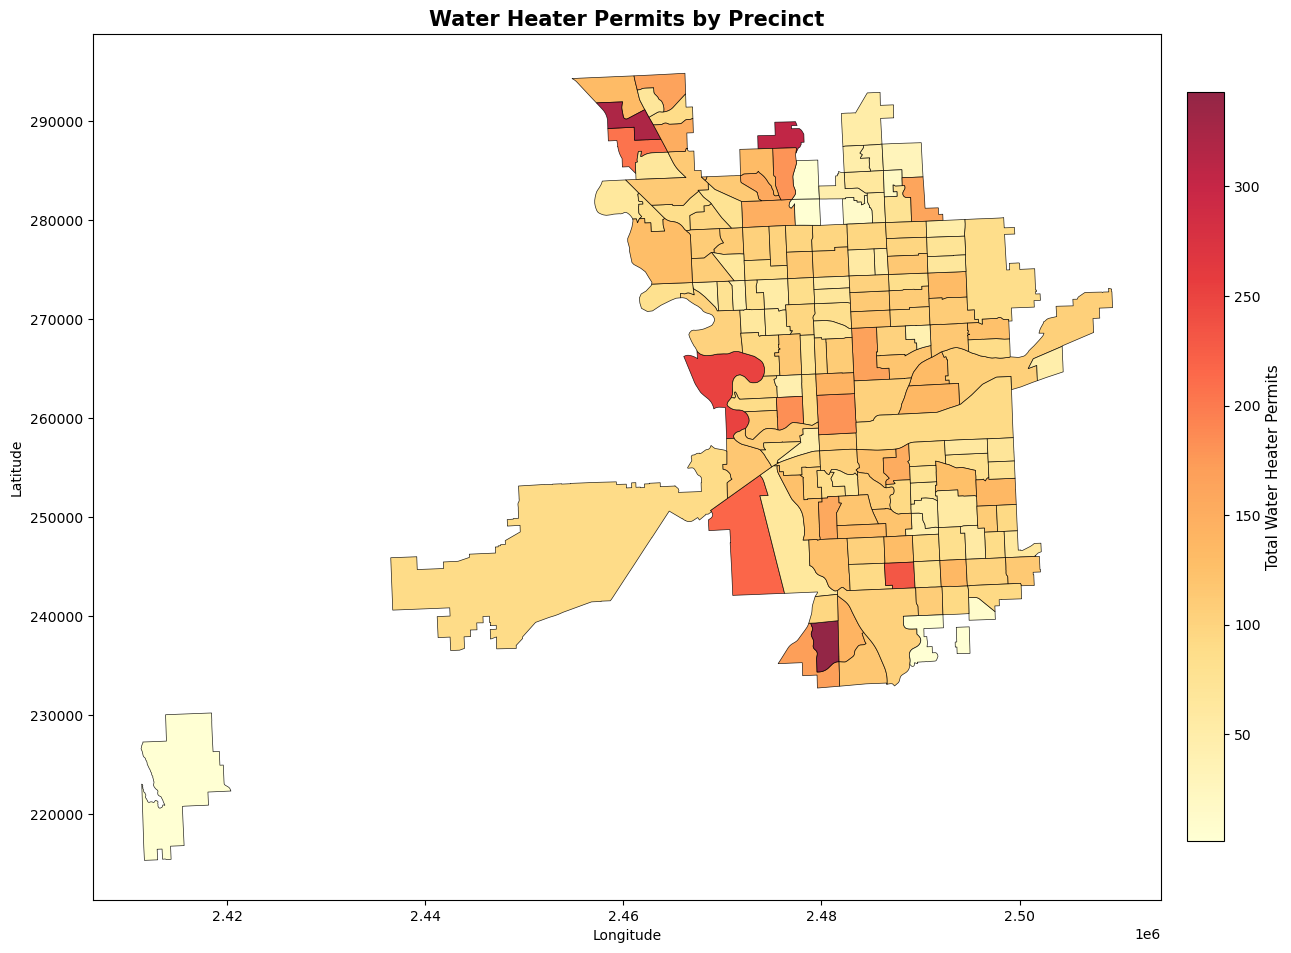

    PrecinctCode  TotalWaterHeaters
58          3247              343.0
163         6315              321.0
154         6306              303.0
11          3200              251.0
52          3241              231.0
38          3227              217.0
150         6302              206.0
97          3329              184.0
155         6307              180.0
10          3110              180.0


In [25]:
import shapefile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
import matplotlib.cm as cm
import numpy as np

# --- 1. Aggregate: sum Quantity per PrecinctCode ---
precinct_quantity = non_dup_address.groupby("PrecinctCode")["Quantity"].sum().reset_index()
precinct_quantity.columns = ["PrecinctCode", "TotalWaterHeaters"]
precinct_quantity["PrecinctCode"] = precinct_quantity["PrecinctCode"].astype(str)

# --- 2. Read shapefile ---
sf = shapefile.Reader("/Users/michaelsegaline/Desktop/Voting_Precincts shape file/Voting_Precincts.shp")
records = sf.records()
shapes = sf.shapes()
fields = [f[0] for f in sf.fields[1:]]
precinct_id_idx = fields.index("PRECINCTID")

shp_dict = {}
for rec, shp in zip(records, shapes):
    pid = str(rec[precinct_id_idx])
    shp_dict[pid] = shp

# --- 3. Build patches and map quantities ---
patches = []
quantity_values = []
unmatched = []

for _, row in precinct_quantity.iterrows():
    pid = row["PrecinctCode"]
    if pid not in shp_dict:
        unmatched.append(pid)
        continue
    shp = shp_dict[pid]

    parts = list(shp.parts) + [len(shp.points)]
    for i in range(len(parts) - 1):
        poly_points = shp.points[parts[i]:parts[i+1]]
        if len(poly_points) < 3:
            continue
        polygon = Polygon(poly_points, closed=True)
        patches.append(polygon)
        quantity_values.append(row["TotalWaterHeaters"])

if unmatched:
    print(f"Warning: {len(unmatched)} precincts unmatched: {unmatched}")

# --- 4. Plot heatmap ---
quantity_array = np.array(quantity_values)
norm = plt.Normalize(vmin=quantity_array.min(), vmax=quantity_array.max())
cmap = cm.YlOrRd  # yellow -> orange -> red for heat effect

p = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor="black", linewidth=0.5, alpha=0.85)
p.set_array(quantity_array)

fig, ax = plt.subplots(figsize=(14, 11))
ax.add_collection(p)
ax.autoscale()
ax.set_aspect("equal")

cbar = plt.colorbar(p, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Total Water Heater Permits", fontsize=11)

ax.set_title("Water Heater Permits by Precinct", fontsize=15, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("Water Heater Permits by Voter Precinct.png")
plt.show()
# --- 5. Preview the aggregated data ---
print(precinct_quantity.sort_values("TotalWaterHeaters", ascending=False).head(10))

# Now exploring electric water heater permits

In [26]:
non_dup_address['Water Heater Type'] =  'Electric Water Heaters'

/var/folders/_5/26fwgmd14qz8pgwfvn4dfky40000gn/T/ipykernel_22203/1913780064.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_dup_address['Water Heater Type'] =  'Electric Water Heaters'


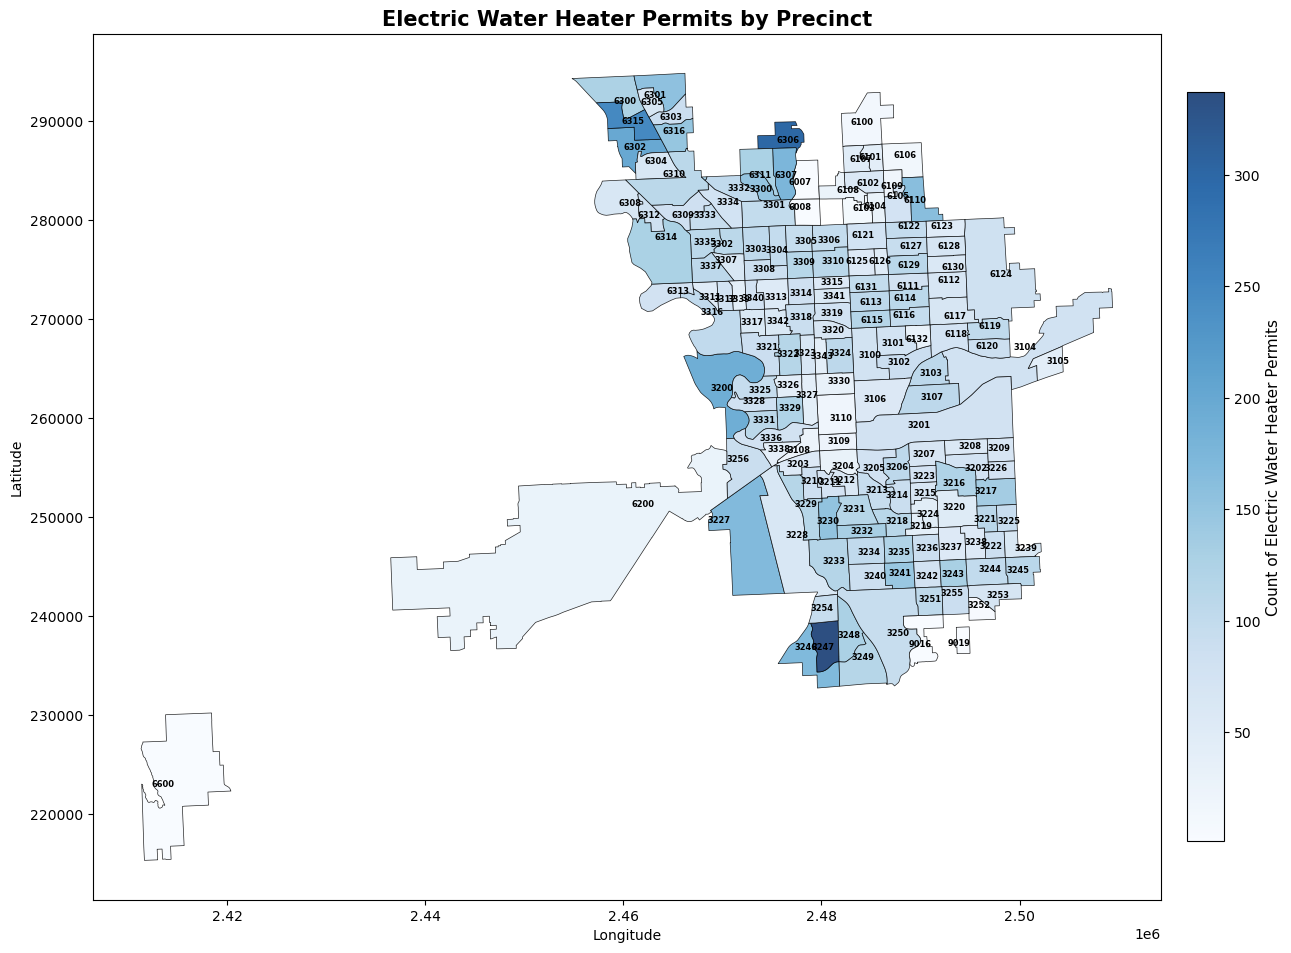

    PrecinctCode  ElectricCount
58          3247            337
154         6306            300
163         6315            249
150         6302            200
11          3200            190
155         6307            175
57          3246            169
38          3227            168
124         6110            162
149         6301            155


In [27]:
# --- 1. Filter Electric Water Heaters and count per PrecinctCode ---
electric = non_dup_address[non_dup_address["Water Heater Type"] == "Electric Water Heaters"]
precinct_quantity = electric.groupby("PrecinctCode").size().reset_index()
precinct_quantity.columns = ["PrecinctCode", "ElectricCount"]
precinct_quantity["PrecinctCode"] = precinct_quantity["PrecinctCode"].astype(str)

# --- 2. Read shapefile ---
#sf = shapefile.Reader("/Users/michaelsegaline/Desktop/Voting_Precincts/Voting_Precincts.shp")
records = sf.records()
shapes = sf.shapes()
fields = [f[0] for f in sf.fields[1:]]
precinct_id_idx = fields.index("PRECINCTID")

shp_dict = {}
for rec, shp in zip(records, shapes):
    pid = str(rec[precinct_id_idx])
    shp_dict[pid] = shp

# --- 3. Build patches and map quantities ---
patches = []
quantity_values = []
unmatched = []

for _, row in precinct_quantity.iterrows():
    pid = row["PrecinctCode"]
    if pid not in shp_dict:
        unmatched.append(pid)
        continue
    shp = shp_dict[pid]
    parts = list(shp.parts) + [len(shp.points)]
    for i in range(len(parts) - 1):
        poly_points = shp.points[parts[i]:parts[i+1]]
        if len(poly_points) < 3:
            continue
        polygon = Polygon(poly_points, closed=True)
        patches.append(polygon)
        quantity_values.append(row["ElectricCount"])

if unmatched:
    print(f"Warning: {len(unmatched)} precincts unmatched: {unmatched}")

# --- 4. Plot heatmap ---
quantity_array = np.array(quantity_values)
norm = plt.Normalize(vmin=quantity_array.min(), vmax=quantity_array.max())
cmap = cm.Blues  # Blue theme for electric

p = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor="black", linewidth=0.5, alpha=0.85)
p.set_array(quantity_array)

fig, ax = plt.subplots(figsize=(14, 11))
ax.add_collection(p)
ax.autoscale()
ax.set_aspect("equal")

# --- 5. Add precinct labels at polygon centroids ---
for _, row in precinct_quantity.iterrows():
    pid = row["PrecinctCode"]
    if pid not in shp_dict:
        continue
    shp = shp_dict[pid]
    all_points = np.array(shp.points)
    centroid_x = all_points[:, 0].mean()
    centroid_y = all_points[:, 1].mean()
    ax.text(
        centroid_x, centroid_y, str(pid),
        fontsize=6,
        ha="center", va="center",
        color="black",
        fontweight="bold",
        clip_on=True
    )

cbar = plt.colorbar(p, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Count of Electric Water Heater Permits", fontsize=11)

ax.set_title("Electric Water Heater Permits by Precinct", fontsize=15, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("Electric Water Heater Permits by Precinct.png")
plt.show()
# --- 6. Preview top precincts ---
print(precinct_quantity.sort_values("ElectricCount", ascending=False).head(10))

# Now comparing electric water heaters and political party

In [28]:
#--Importing the census data to explore poltical senitment --#
party = pd.read_csv('/Users/michaelsegaline/Desktop/Washington GOP/2024-3 Washington State Party Identification Census/Spokane.csv')

In [29]:
party.columns

Index(['Ballot ID', 'Voter ID', 'County', 'First Name', 'Last Name', 'Gender',
       'Election', 'Ballot Status', 'Challenge Reason', 'Sent Date',
       'Received Date', 'Address', 'City', 'State', 'Zip', 'Country', 'Split',
       'Precinct', 'Return Method', 'Return Location', 'Party'],
      dtype='object')

In [30]:
non_dup_address.columns

Index(['Record ID', 'Water Heater Type', 'Quantity', 'Open Date', 'Address',
       'City', 'State', 'open_year', 'open_month', 'open_day', 'StateVoterID',
       'FName', 'MName', 'LName', 'NameSuffix', 'Birthyear', 'Gender',
       'RegStNum', 'RegStFrac', 'RegStName', 'RegStType', 'RegUnitType',
       'RegStPreDirection', 'RegStPostDirection', 'RegStUnitNum', 'RegCity',
       'RegState', 'RegZipCode', 'CountyCode', 'PrecinctCode', 'PrecinctPart',
       'LegislativeDistrict', 'CongressionalDistrict', 'Mail1', 'Mail2',
       'Mail3', 'MailCity', 'MailZip', 'MailState', 'MailCountry',
       'Registrationdate', 'LastVoted', 'StatusCode', 'Count', 'Reg Month',
       'Reg Year', 'First name = middle name', 'first name = last name'],
      dtype='object')

In [31]:
non_dup_address_party = non_dup_address.merge(party, left_on="StateVoterID", right_on="Voter ID", how="left")

In [32]:
non_dup_address_party.columns

Index(['Record ID', 'Water Heater Type', 'Quantity', 'Open Date', 'Address_x',
       'City_x', 'State_x', 'open_year', 'open_month', 'open_day',
       'StateVoterID', 'FName', 'MName', 'LName', 'NameSuffix', 'Birthyear',
       'Gender_x', 'RegStNum', 'RegStFrac', 'RegStName', 'RegStType',
       'RegUnitType', 'RegStPreDirection', 'RegStPostDirection',
       'RegStUnitNum', 'RegCity', 'RegState', 'RegZipCode', 'CountyCode',
       'PrecinctCode', 'PrecinctPart', 'LegislativeDistrict',
       'CongressionalDistrict', 'Mail1', 'Mail2', 'Mail3', 'MailCity',
       'MailZip', 'MailState', 'MailCountry', 'Registrationdate', 'LastVoted',
       'StatusCode', 'Count', 'Reg Month', 'Reg Year',
       'First name = middle name', 'first name = last name', 'Ballot ID',
       'Voter ID', 'County', 'First Name', 'Last Name', 'Gender_y', 'Election',
       'Ballot Status', 'Challenge Reason', 'Sent Date', 'Received Date',
       'Address_y', 'City_y', 'State_y', 'Zip', 'Country', 'Split', 'Prec

In [33]:
matched = non_dup_address_party["StateVoterID"].notna().sum()
unmatched = non_dup_address_party["StateVoterID"].isna().sum()
print(f"Matched: {matched} | Unmatched: {unmatched}")

Matched: 14454 | Unmatched: 0


In [34]:
4772/14454

0.33015082330150824

plt.figure(figsize=(10, 6))
sns.countplot(data=non_dup_address, x="Party", order=non_dup_address["Party"].value_counts().index)

plt.title("Distribution of Water Heater Permits by Party", fontsize=14, fontweight="bold")
plt.xlabel("Party")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

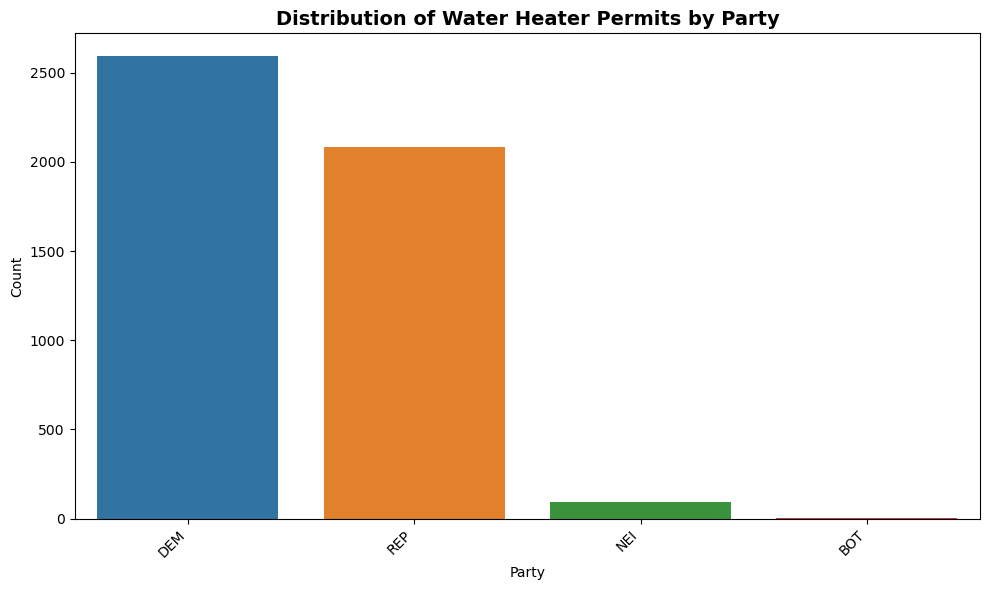

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(data=non_dup_address_party, x="Party", order=non_dup_address_party["Party"].value_counts().index)

plt.title("Distribution of Water Heater Permits by Party", fontsize=14, fontweight="bold")
plt.xlabel("Party")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("Water heater permits by political partry.png")
plt.show()

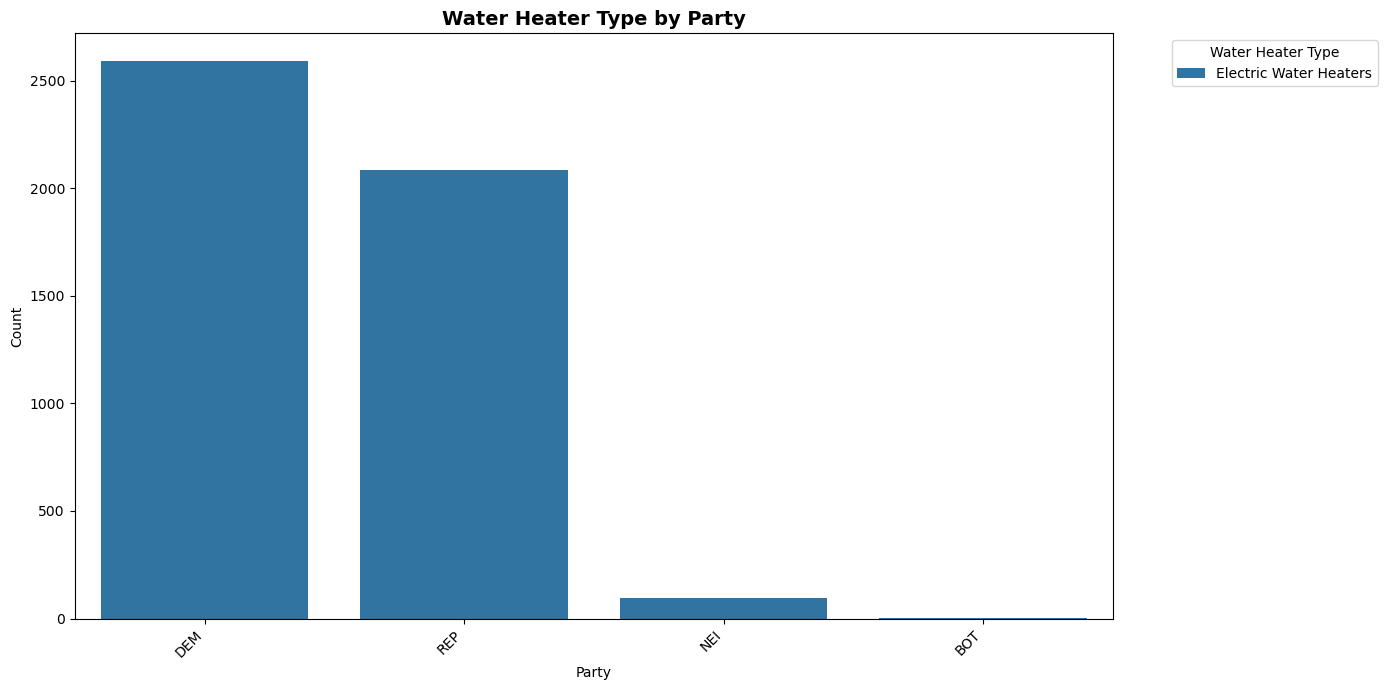

In [36]:
plt.figure(figsize=(14, 7))
sns.countplot(
    data=non_dup_address_party,
    x="Party",
    hue="Water Heater Type",
    order=non_dup_address_party["Party"].value_counts().index
)

plt.title("Water Heater Type by Party", fontsize=14, fontweight="bold")
plt.xlabel("Party")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Water Heater Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("water heater type by political party.png")
plt.show()

# What is the average age of a person that submits a water heater permit?

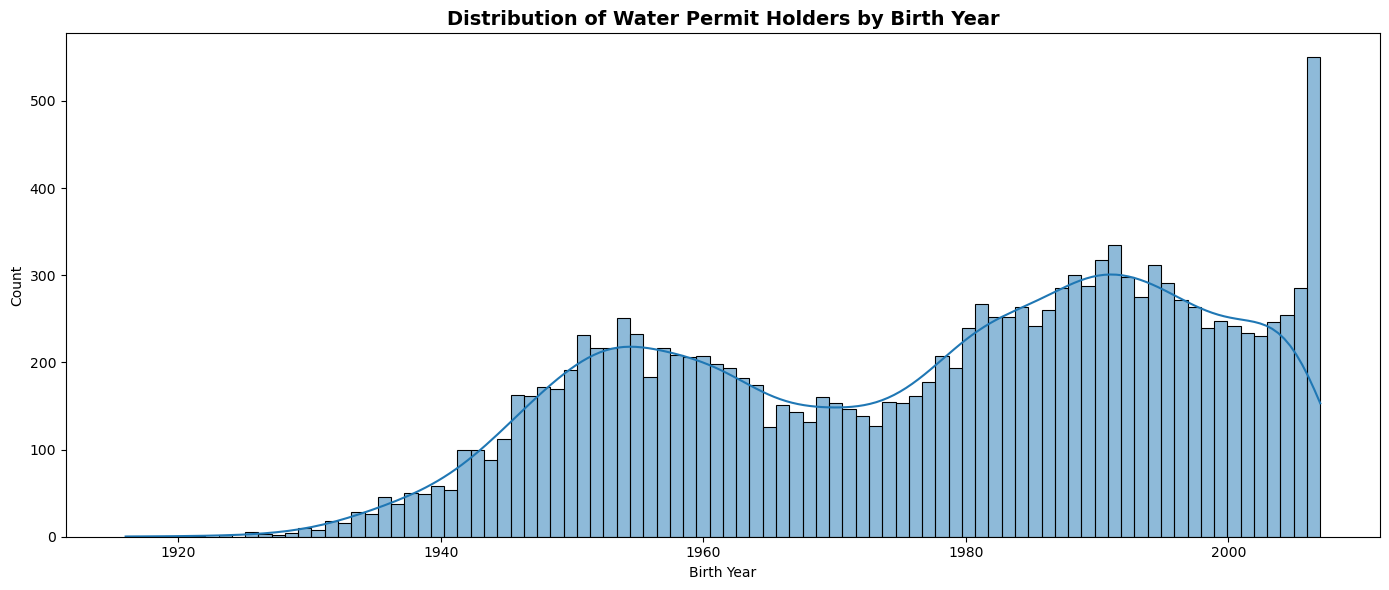

In [37]:
plt.figure(figsize=(14, 6))
sns.histplot(data=non_dup_address, x="Birthyear", bins=90, kde=True)

plt.title("Distribution of Water Permit Holders by Birth Year", fontsize=14, fontweight="bold")
plt.xlabel("Birth Year")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Permit holder ages.png")
plt.show()

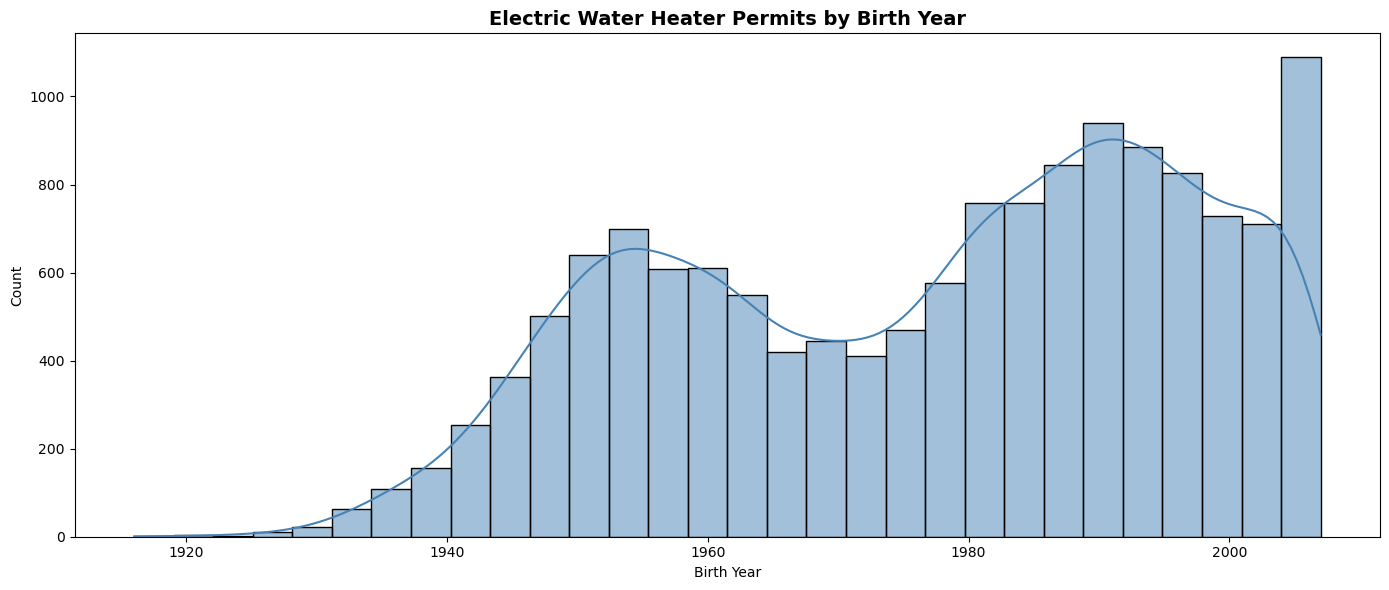

In [73]:
electric_only = non_dup_address[non_dup_address["Water Heater Type"] == "Electric Water Heaters"]

plt.figure(figsize=(14, 6))
sns.histplot(data=electric_only, x="Birthyear", bins=30, kde=True, color="steelblue")

plt.title("Electric Water Heater Permits by Birth Year", fontsize=14, fontweight="bold")
plt.xlabel("Birth Year")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("Ages of Electric heater permits.png")
plt.show()

In [39]:
# How many total gas vs electric in original df
print(df["Water Heater Type"].value_counts())

# How many gas addresses have exactly 2 permits
gas_df = df[df["Water Heater Type"] == "Gas Water Heaters"].copy()
gas_counts = gas_df.groupby("Address").size()
print(f"\nGas addresses with exactly 2 permits: {(gas_counts == 2).sum()}")
print(f"Gas addresses with 1 permit: {(gas_counts == 1).sum()}")
print(f"Gas addresses with 3+ permits: {(gas_counts >= 3).sum()}")

Gas Water Heaters < 200,000 BTU input    13817
Electric Water Heaters                    6198
Name: Water Heater Type, dtype: int64

Gas addresses with exactly 2 permits: 0
Gas addresses with 1 permit: 0
Gas addresses with 3+ permits: 0


# 757 gas-to-gas replacements vs 261 electric-to-electric — gas dominates same-type replacements, consistent with it being 2x more common in the dataset
344 type-switchers is surprisingly high — meaning roughly 25% of addresses changed heater type, mostly likely gas-to-electric conversions worth exploring later

In [40]:
heater_df = df[df["Water Heater Type"].isin([
    "Electric Water Heaters",
    "Gas Water Heaters < 200,000 BTU input"
])].copy()

heater_df = heater_df.sort_values(["Address", "open_year"])

# Exactly 2 permits per address
address_counts = heater_df.groupby("Address").size()
exactly_two = address_counts[address_counts == 2].index
heater_df_two = heater_df[heater_df["Address"].isin(exactly_two)].copy()

# Check pair types
pair_types = heater_df_two.groupby("Address")["Water Heater Type"].apply(list).reset_index()
pair_types.columns = ["Address", "TypePair"]
pair_types["TypePair"] = pair_types["TypePair"].apply(lambda x: " -> ".join(sorted(x)))
print(pair_types["TypePair"].value_counts())

Gas Water Heaters < 200,000 BTU input -> Gas Water Heaters < 200,000 BTU input    757
Electric Water Heaters -> Gas Water Heaters < 200,000 BTU input                   344
Electric Water Heaters -> Electric Water Heaters                                  261
Name: TypePair, dtype: int64


             mean  median  min   max  count
Type                                       
Electric  4.54023     3.0  0.0  18.0    261
Gas       9.00000    10.0  0.0  19.0    757


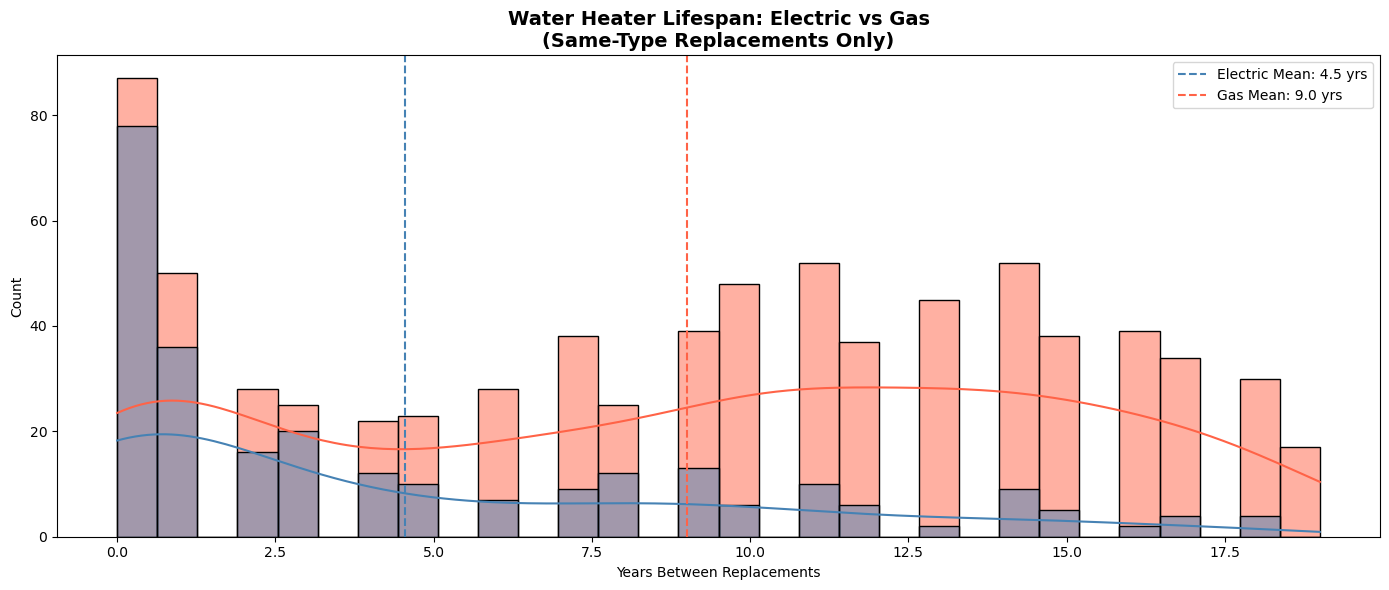

In [41]:
# --- Filter to same-type replacements only ---#
same_type_addresses = pair_types[pair_types["TypePair"].isin([
    "Gas Water Heaters < 200,000 BTU input -> Gas Water Heaters < 200,000 BTU input",
    "Electric Water Heaters -> Electric Water Heaters"
])]["Address"]

same_type_df = heater_df_two[heater_df_two["Address"].isin(same_type_addresses)].copy()

# --- Calculate years between ---#
same_type_df["prev_year"] = same_type_df.groupby("Address")["open_year"].shift(1)
same_type_df["years_between"] = same_type_df["open_year"] - same_type_df["prev_year"]
replacement_cycles = same_type_df.dropna(subset=["years_between"]).copy()

# --- Simplify label for plot ---#
replacement_cycles["Type"] = replacement_cycles["Water Heater Type"].map({
    "Electric Water Heaters": "Electric",
    "Gas Water Heaters < 200,000 BTU input": "Gas"
})

print(replacement_cycles.groupby("Type")["years_between"].agg(["mean", "median", "min", "max", "count"]))

# --- Plot ---#
elec_mean = replacement_cycles[replacement_cycles["Type"] == "Electric"]["years_between"].mean()
gas_mean = replacement_cycles[replacement_cycles["Type"] == "Gas"]["years_between"].mean()

plt.figure(figsize=(14, 6))
sns.histplot(
    data=replacement_cycles,
    x="years_between",
    hue="Type",
    bins=30,
    kde=True,
    palette={"Electric": "steelblue", "Gas": "tomato"}
)

plt.axvline(x=elec_mean, color="steelblue", linestyle="--", label=f"Electric Mean: {elec_mean:.1f} yrs")
plt.axvline(x=gas_mean, color="tomato", linestyle="--", label=f"Gas Mean: {gas_mean:.1f} yrs")

plt.title("Water Heater Lifespan: Electric vs Gas\n(Same-Type Replacements Only)", fontsize=14, fontweight="bold")
plt.xlabel("Years Between Replacements")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("Water heater Lifespan: Electric vs Gas.png")
plt.show()

# Gas lasts roughly twice as long as Electric in Spokane? Now inspecting the outliers

In [42]:

heater_df = merged.sort_values(["Address", "open_year"])

address_counts = heater_df.groupby("Address").size()
exactly_two = address_counts[address_counts == 2].index
heater_df_two = heater_df[heater_df["Address"].isin(exactly_two)].copy()

pair_types = heater_df_two.groupby("Address")["Water Heater Type"].apply(list).reset_index()
pair_types.columns = ["Address", "TypePair"]
pair_types["TypePair"] = pair_types["TypePair"].apply(lambda x: " -> ".join(sorted(x)))

same_type_addresses = pair_types[pair_types["TypePair"].isin([
    "Gas Water Heaters < 200,000 BTU input -> Gas Water Heaters < 200,000 BTU input",
    "Electric Water Heaters -> Electric Water Heaters"
])]["Address"]

same_type_df = heater_df_two[heater_df_two["Address"].isin(same_type_addresses)].copy()
same_type_df["prev_year"] = same_type_df.groupby("Address")["open_year"].shift(1)
same_type_df["years_between"] = same_type_df["open_year"] - same_type_df["prev_year"]



replacement_cycles = same_type_df.dropna(subset=["years_between"]).copy()
replacement_cycles["Type"] = replacement_cycles["Water Heater Type"].map({
    "Electric Water Heaters": "Electric",
    "Gas Water Heaters < 200,000 BTU input": "Gas"
})

# Correct filter - only remove 0 year replacements
replacement_cycles = replacement_cycles[replacement_cycles["years_between"] > 0].copy()

# --- Now run the spike analysis ---
short_cycle = replacement_cycles[replacement_cycles["years_between"] <= 1]

print(f"Count of 0-1 year replacements: {len(short_cycle)}")
print(f"\nBy Type:")
print(short_cycle.groupby("Type")["years_between"].count())
print(f"\nBy Open Year:")
print(short_cycle["open_year"].value_counts().head(10))
print(f"\nBy Precinct:")
print(short_cycle["PrecinctCode"].value_counts().head(10))

Count of 0-1 year replacements: 11

By Type:
Type
Electric    3
Gas         8
Name: years_between, dtype: int64

By Open Year:
2013.0    3
2011.0    1
2020.0    1
2016.0    1
2022.0    1
2014.0    1
2019.0    1
2015.0    1
2021.0    1
Name: open_year, dtype: int64

By Precinct:
3203    1
3235    1
3255    1
3216    1
3221    1
3209    1
6121    1
6129    1
3205    1
3100    1
Name: PrecinctCode, dtype: int64


# Now inspecting the lifespan of water heaters given the outlier removal.

               mean  median  min   max  count
Type                                         
Electric  10.736842    10.0  5.0  17.0     19
Gas       11.902655    12.0  5.0  19.0    113


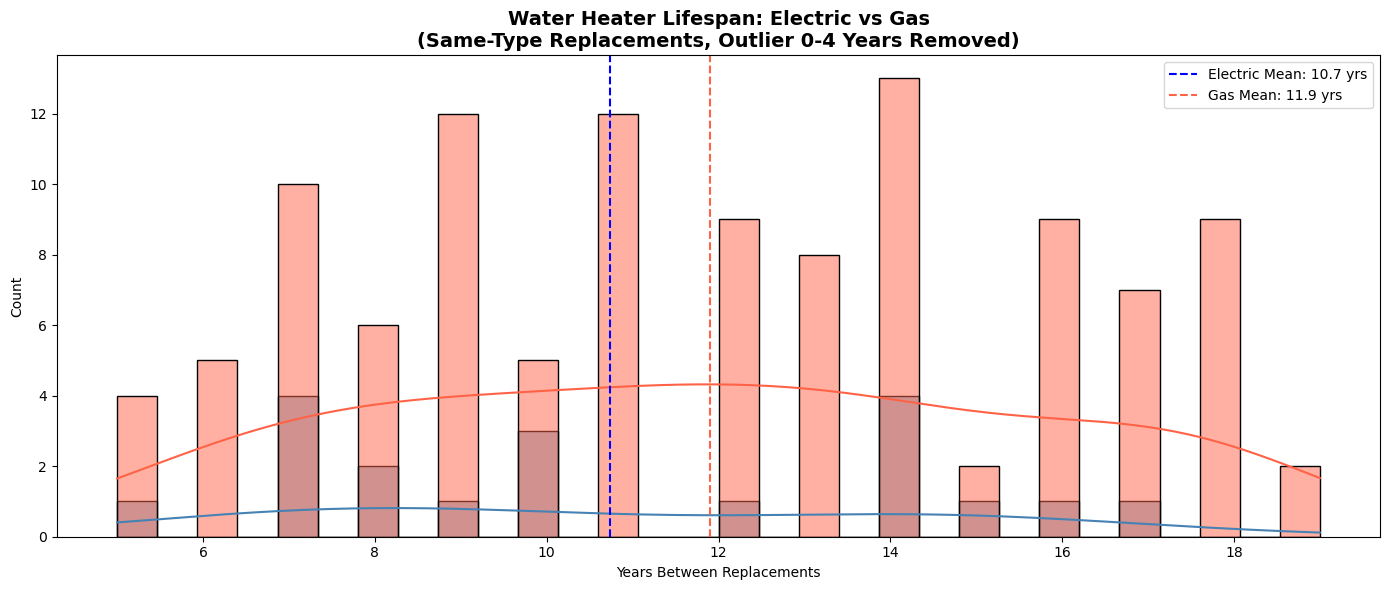

In [78]:
# --- Filter to same-type replacements only ---#
same_type_addresses = pair_types[pair_types["TypePair"].isin([
    "Gas Water Heaters < 200,000 BTU input -> Gas Water Heaters < 200,000 BTU input",
    "Electric Water Heaters -> Electric Water Heaters"
])]["Address"]

same_type_df = heater_df_two[heater_df_two["Address"].isin(same_type_addresses)].copy()

# --- Calculate years between ---#
same_type_df["prev_year"] = same_type_df.groupby("Address")["open_year"].shift(1)
same_type_df["years_between"] = same_type_df["open_year"] - same_type_df["prev_year"]

replacement_cycles = same_type_df.dropna(subset=["years_between"]).copy()

# --- Remove noise: filter out 0-4 year replacements ---#
# Correct filter - only remove 0 -4 year replacements
replacement_cycles = replacement_cycles[replacement_cycles["years_between"] > 4].copy()

# --- Simplify label for plot ---#
replacement_cycles["Type"] = replacement_cycles["Water Heater Type"].map({
    "Electric Water Heaters": "Electric",
    "Gas Water Heaters < 200,000 BTU input": "Gas"
})

print(replacement_cycles.groupby("Type")["years_between"].agg(["mean", "median", "min", "max", "count"]))

# --- Plot ---#
elec_mean = replacement_cycles[replacement_cycles["Type"] == "Electric"]["years_between"].mean()
gas_mean = replacement_cycles[replacement_cycles["Type"] == "Gas"]["years_between"].mean()

plt.figure(figsize=(14, 6))
sns.histplot(
    data=replacement_cycles,
    x="years_between",
    hue="Type",
    bins=30,
    kde=True,
    palette={"Electric": "steelblue", "Gas": "tomato"}
)

plt.axvline(x=elec_mean, color="blue", linestyle="--", label=f"Electric Mean: {elec_mean:.1f} yrs")
plt.axvline(x=gas_mean, color="tomato", linestyle="--", label=f"Gas Mean: {gas_mean:.1f} yrs")

plt.title("Water Heater Lifespan: Electric vs Gas\n(Same-Type Replacements, Outlier 0-4 Years Removed)", fontsize=14, fontweight="bold")
plt.xlabel("Years Between Replacements")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("WaterHeaterLifespans 0-4 outlier years removed.png")
plt.show()

# Statisitcal testing on distrobutions

Now the outliers for factory failures in the 0-1 years are dropped, we will conduct testing using Shapiro Wilk for normality on the gas heaters then use kruskal wallis to compare the distrobutions of both gas and electric.

In [79]:
from scipy import stats

# --- Split into individual groups ---#
electric_cycles = replacement_cycles[replacement_cycles["Type"] == "Electric"]["years_between"]
gas_cycles = replacement_cycles[replacement_cycles["Type"] == "Gas"]["years_between"]

# --- Shapiro-Wilk on Gas (normality test) ---#
# Note: Shapiro-Wilk is most reliable for n < 5000
print(f"Gas sample size: {len(gas_cycles)}")
stat_sw, p_sw = stats.shapiro(gas_cycles)
print(f"\nShapiro-Wilk Test (Gas):")
print(f"  Statistic: {stat_sw:.4f}")
print(f"  p-value:   {p_sw:.4f}")
if p_sw < 0.05:
    print("  → Reject normality (p < 0.05): Gas distribution is NOT normal")
else:
    print("  → Fail to reject normality (p >= 0.05): Gas distribution may be normal")

# --- Kruskal-Wallis (Gas vs Electric) ---#
stat_kw, p_kw = stats.kruskal(electric_cycles, gas_cycles)
print(f"\nKruskal-Wallis Test (Electric vs Gas):")
print(f"  Statistic: {stat_kw:.4f}")
print(f"  p-value:   {p_kw:.4f}")
if p_kw < 0.05:
    print("  → Significant difference (p < 0.05): The two distributions are NOT from the same population")
else:
    print("  → No significant difference (p >= 0.05): Cannot distinguish the two distributions")

Gas sample size: 113

Shapiro-Wilk Test (Gas):
  Statistic: 0.9589
  p-value:   0.0016
  → Reject normality (p < 0.05): Gas distribution is NOT normal

Kruskal-Wallis Test (Electric vs Gas):
  Statistic: 1.3638
  p-value:   0.2429
  → No significant difference (p >= 0.05): Cannot distinguish the two distributions


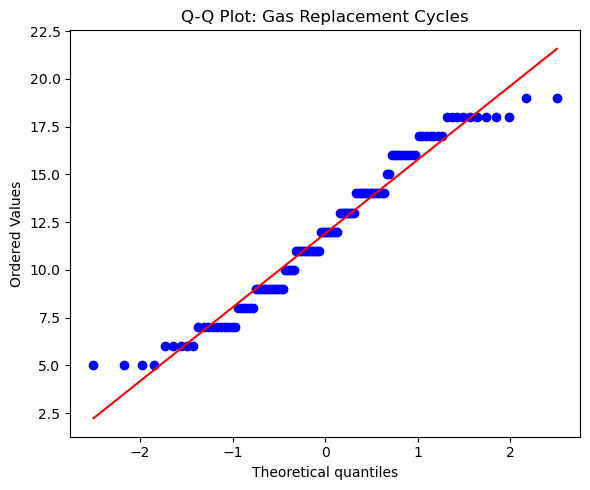

In [80]:
fig, ax = plt.subplots(figsize=(6, 5))
stats.probplot(gas_cycles, dist="norm", plot=ax)
ax.set_title("Q-Q Plot: Gas Replacement Cycles")
plt.tight_layout()
plt.savefig("QQ Plot Gas.png", bbox_inches='tight', dpi=150)
plt.show()

In [81]:
stat_mw, p_mw = stats.mannwhitneyu(electric_cycles, gas_cycles, alternative='two-sided')
print(f"\nMann-Whitney U Test:")
print(f"  Statistic: {stat_mw:.4f}")
print(f"  p-value:   {p_mw:.4f}")
print(f"\n  Electric median: {electric_cycles.median():.1f} years")
print(f"  Gas median:      {gas_cycles.median():.1f} years")


Mann-Whitney U Test:
  Statistic: 894.0000
  p-value:   0.2442

  Electric median: 10.0 years
  Gas median:      12.0 years


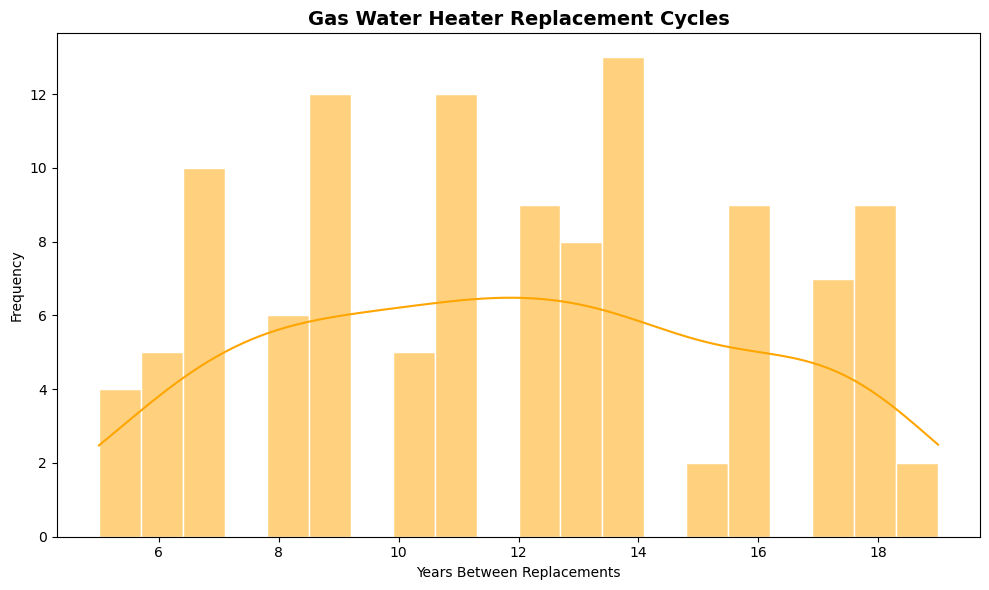

In [82]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=gas_cycles,
    bins=20,
    color="orange",
    edgecolor="white",
    kde=True          # overlays the trendline you mentioned seeing earlier
)

plt.title("Gas Water Heater Replacement Cycles", fontsize=14, fontweight="bold")
plt.xlabel("Years Between Replacements")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Gas Replacement Cycles.png", bbox_inches="tight", dpi=150)
plt.show()

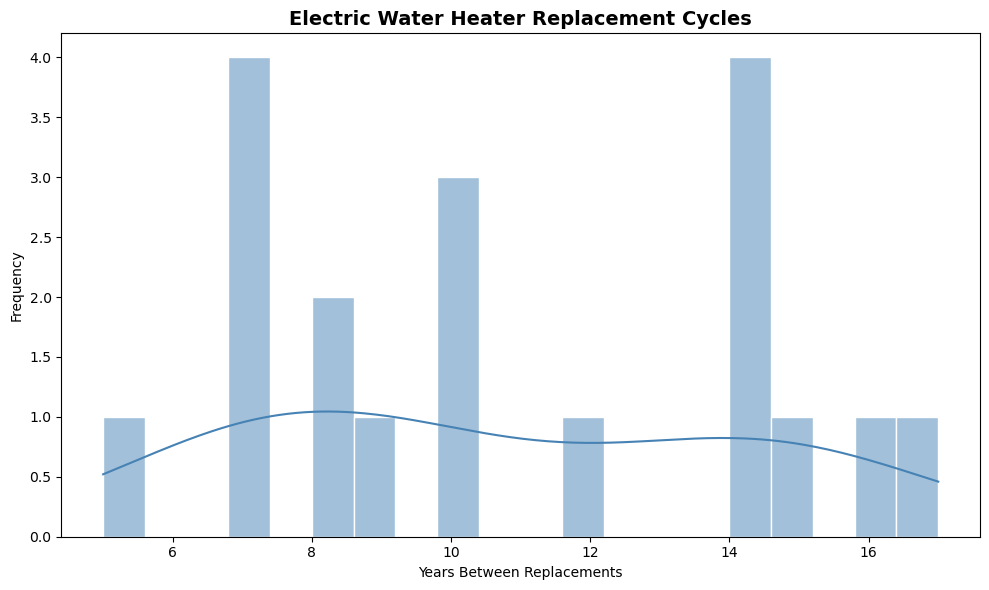

In [83]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=electric_cycles,
    bins=20,
    color="steelblue",
    edgecolor="white",
    kde=True          # overlays the trendline you mentioned seeing earlier
)

plt.title("Electric Water Heater Replacement Cycles", fontsize=14, fontweight="bold")
plt.xlabel("Years Between Replacements")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("Electric Replacement Cycles.png", bbox_inches="tight", dpi=150)
plt.show()

# Now comparing residential new build permit locations against water heater locations

In [44]:
#-- Importing the dataset of Spokane residential new build permits --#
df3 = pd.read_csv("/Users/michaelsegaline/Desktop/Spokane permits/Spokane Residential Permits /Residential_Square_Footage_PRR_3.6.2025.csv")

In [45]:
df3.street

0          1807 W INDIANA AVE
1         1005 E COLUMBIA AVE
2         2022 W STRATTON AVE
3       916 W STIRLINGVIEW DR
4            1014 E BROAD AVE
                ...          
4963          3137 E 36TH AVE
4964          1037 E 27TH AVE
4965          1111 E 27TH AVE
4966           3609 E 8TH AVE
4967           3613 E 8TH AVE
Name: street, Length: 4968, dtype: object

Now connecting residential new builds permit data to the voter data

In [46]:
df2.Address

0                857 E LYONS AVE
1          15917 W PINE BLUFF RD
2                  3402 N LEE ST
3                3104 E 18TH AVE
4             22250 E BENNETT LN
                   ...          
403677    10425 W SALMONBERRY RD
403678      1024 W MANSFIELD AVE
403679           4201 E MOODY LN
403680          4123 E LAUREL RD
403681      22751 E APPLEWAY AVE
Name: Address, Length: 403682, dtype: object

In [47]:
#-- Merging the datasets--#
newresbuild_waterheaters = df2.merge(df3, left_on="Address", right_on="street", how="inner")

In [48]:
newresbuild_waterheaters.columns

Index(['StateVoterID', 'FName', 'MName', 'LName', 'NameSuffix', 'Birthyear',
       'Gender', 'RegStNum', 'RegStFrac', 'RegStName', 'RegStType',
       'RegUnitType', 'RegStPreDirection', 'RegStPostDirection',
       'RegStUnitNum', 'RegCity', 'RegState', 'RegZipCode', 'CountyCode',
       'PrecinctCode', 'PrecinctPart', 'LegislativeDistrict',
       'CongressionalDistrict', 'Mail1', 'Mail2', 'Mail3', 'MailCity',
       'MailZip', 'MailState', 'MailCountry', 'Registrationdate', 'LastVoted',
       'StatusCode', 'Count', 'Reg Month', 'Reg Year',
       'First name = middle name', 'first name = last name', 'Address',
       'RECORD_ID', 'RECORD_OPEN_DATE', 'Combined Code and Description',
       'Sum of Total Square Footage', 'street', 'city', 'state'],
      dtype='object')

In [49]:
#newresbuild_waterheaters.to_csv("/Users/michaelsegaline/Desktop/Water Heater permits analysis/Spokanenewbuilds_waterheaters.csv")

In [50]:
#-- Now dropping all instances with duplicate RECORD_ID --#
newresbuild_waterheaters = newresbuild_waterheaters[~newresbuild_waterheaters.duplicated(subset="RECORD_ID", keep=False)]

In [51]:
newresbuild_waterheaters.shape

(985, 46)

In [52]:
newresbuild_waterheaters["Quantity"] = 1

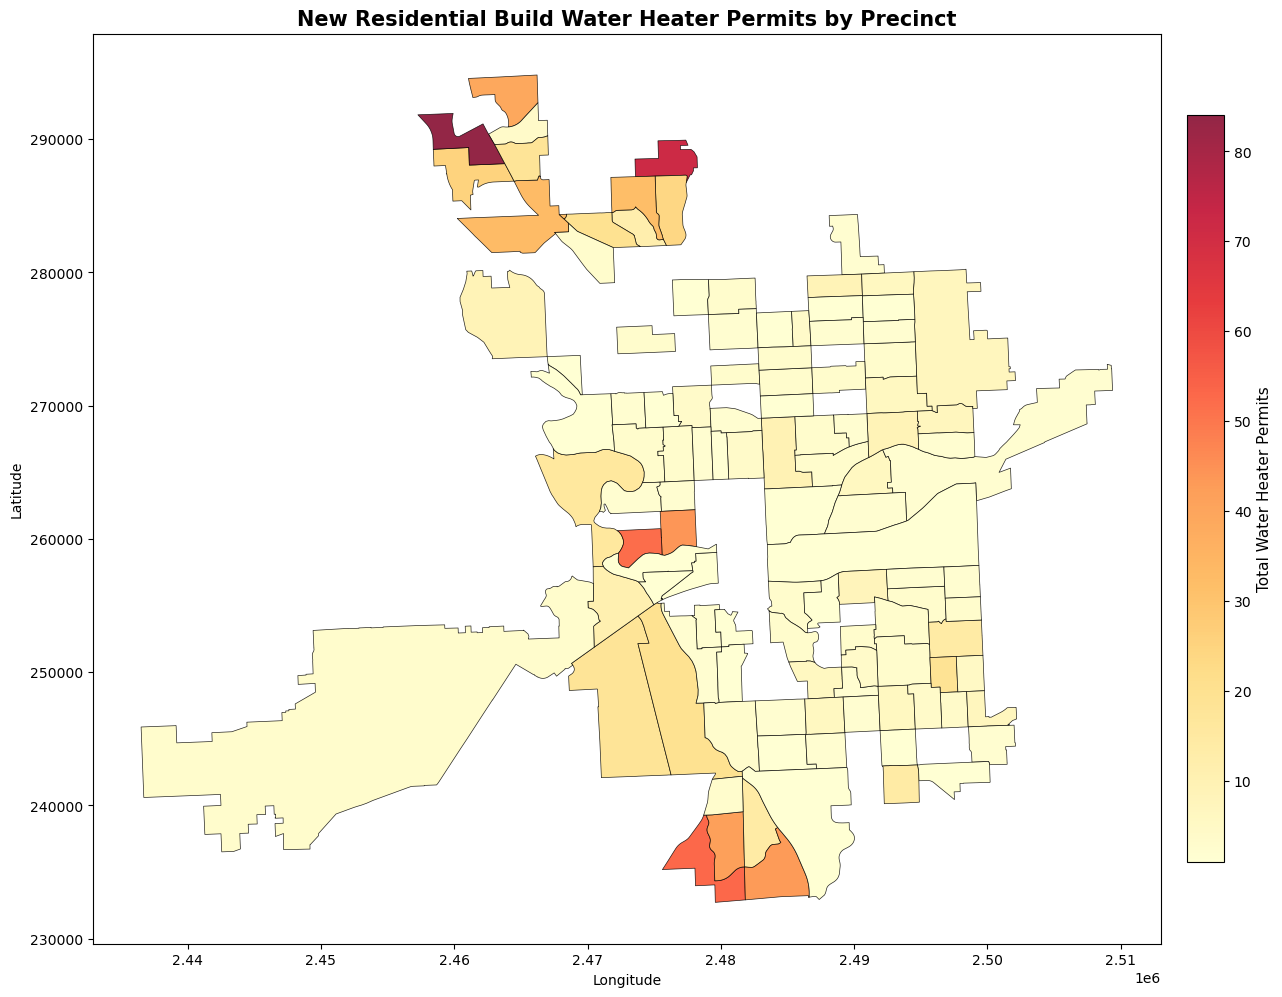

    PrecinctCode  TotalWaterHeaters
108         6315                 84
103         6306                 72
45          3246                 53
71          3331                 52
70          3329                 44
48          3249                 43
46          3247                 42
100         6301                 39
105         6310                 33
106         6311                 32


In [53]:
precinct_quantity = (
    newresbuild_waterheaters
    .groupby("PrecinctCode")
    .size()
    .reset_index(name="TotalWaterHeaters")
)

# --- 1. Aggregate: sum Quantity per PrecinctCode ---
precinct_quantity = newresbuild_waterheaters.groupby("PrecinctCode")["Quantity"].sum().reset_index()
precinct_quantity.columns = ["PrecinctCode", "TotalWaterHeaters"]
precinct_quantity["PrecinctCode"] = precinct_quantity["PrecinctCode"].astype(str)

# --- 2. Read shapefile ---
sf = shapefile.Reader("/Users/michaelsegaline/Desktop/Voting_Precincts shape file/Voting_Precincts.shp")
records = sf.records()
shapes = sf.shapes()
fields = [f[0] for f in sf.fields[1:]]
precinct_id_idx = fields.index("PRECINCTID")

shp_dict = {}
for rec, shp in zip(records, shapes):
    pid = str(rec[precinct_id_idx])
    shp_dict[pid] = shp

# --- 3. Build patches and map quantities ---
patches = []
quantity_values = []
unmatched = []

for _, row in precinct_quantity.iterrows():
    pid = row["PrecinctCode"]
    if pid not in shp_dict:
        unmatched.append(pid)
        continue
    shp = shp_dict[pid]

    parts = list(shp.parts) + [len(shp.points)]
    for i in range(len(parts) - 1):
        poly_points = shp.points[parts[i]:parts[i+1]]
        if len(poly_points) < 3:
            continue
        polygon = Polygon(poly_points, closed=True)
        patches.append(polygon)
        quantity_values.append(row["TotalWaterHeaters"])

if unmatched:
    print(f"Warning: {len(unmatched)} precincts unmatched: {unmatched}")

# --- 4. Plot heatmap ---
quantity_array = np.array(quantity_values)
norm = plt.Normalize(vmin=quantity_array.min(), vmax=quantity_array.max())
cmap = cm.YlOrRd  # yellow -> orange -> red for heat effect

p = PatchCollection(patches, cmap=cmap, norm=norm, edgecolor="black", linewidth=0.5, alpha=0.85)
p.set_array(quantity_array)

fig, ax = plt.subplots(figsize=(14, 11))
ax.add_collection(p)
ax.autoscale()
ax.set_aspect("equal")

cbar = plt.colorbar(p, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Total Water Heater Permits", fontsize=11)

ax.set_title("New Residential Build Water Heater Permits by Precinct", fontsize=15, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("New Residential Water Heater Permits by precinct.png")
plt.show()
# --- 5. Preview the aggregated data ---
print(precinct_quantity.sort_values("TotalWaterHeaters", ascending=False).head(10))

 985 new build permits matched with the water heaters, that have been matched with voter data. 

# Now making the PDF report

In [54]:
#-- Create PDF --#
pdf_file = "Spokane Water Heater Report.pdf"
doc = SimpleDocTemplate(pdf_file, pagesize=letter)
story = []

styles = getSampleStyleSheet()
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Paragraph(f"<b>Spokane Water Heater Report</b>", styles["Title"]))
story.append(Spacer(1, 20))
story.append(Paragraph(f"Latest Data Available from the last 20 years"))
story.append(Spacer(1, 20))

story.append(Image("Distobution of Quantity.png", width=600, height=600))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Image("Water Heater Type.png", width=400, height=250))
story.append(Spacer(1, 20))
story.append(Spacer(1, 20))
story.append(Image("All Months.png", width=400, height=250))
story.append(Spacer(1, 20))
story.append(Image("All days.png", width=400, height=250))
story.append(Spacer(1, 20))
story.append(Image("All Years.png", width=400, height=250))

story.append(Image("Electric Permit Time Distrobutions.png",width =600,height =600))
story.append(Spacer(1, 20))
story.append(Image("Water Heater Permits by Voter Precinct.png", width=400, height=250))


story.append(Spacer(1, 20))
story.append(Image("Water heater Lifespan: Electric vs Gas.png", width=400, height=250))

story.append(Spacer(1, 20))
story.append(Image("Water heater permits by political partry.png", width=400, height=250))

story.append(Spacer(1, 20))
story.append(Image("water heater type by political party.png", width=400, height=250))
story.append(Spacer(1, 20))
story.append(Image("Permit holder ages.png", width=400, height=250))
story.append(Spacer(1, 20))
story.append(Image("Ages of Electric heater permits.png", width=400, height=250))



story.append(Image("Permit holder ages.png", width=400, height=250))
story.append(Spacer(1, 20))
story.append(Image("WaterHeaterLifespans 0-1 outlier years removed.png", width=400, height=250))




# Example of adding an image (modify with your real plots)
story.append(Image("New Residential Water Heater Permits by precinct.png", width=400, height=250))

# Build PDF
doc.build(story)

print(f"PDF report generated: {pdf_file}")

PDF report generated: Spokane Water Heater Report.pdf
